# Import packages

In [1]:
library(DESeq2)
library(dplyr)
library(ggplot2)
library(dplyr)
library(tidyr)
library(ggpubr)
library(clusterProfiler)
library(enrichplot)
library(dplyr)
library(tibble)
library(enrichplot)
library(cowplot)

# Load bulk RNA-seq data

In [2]:
expr=read.csv('/home/lixinxing/IBD/dnt_mac_bulk/20260130/expr3+2.csv',row.names = 1,check.names = FALSE)
expr

,R_B567A_HMDM,R_B567A_HMDM+LPS-IFNg,R_B567A_HMDM+LPS-IFNg+DNT,UNT_B568A_HMDM,UNT_B568A_HMDM+LPS-IFNg,UNT_B568A_HMDM+LPS-IFNg+DNT,anti-TNF_NR_B572A_HMDM,anti-TNF_NR_B572A_HMDM+LPS-IFNg,anti-TNF_NR_B572A_HMDM+LPS-IFNg+DNT,UNT_B573A_HMDM,⋯,M2,M4,M5,M6,M7,M8,M9,M10,M11,M12
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
5_8S_rRNA,2,7,1,7,0,4,1,2,0,5,⋯,0,1,1,0,0,2,1,0,0,0
5S_rRNA,89,2,16,0,39,0,0,2,0,3,⋯,0,0,0,1,0,0,0,0,0,0
7SK,0,22,25,1,4,4,2,0,0,12,⋯,0,0,0,0,0,4,1,0,0,0
A1BG,52,0,13,15,103,3,2,8,0,46,⋯,0,0,0,0,0,0,0,0,0,6
A1BG-AS1,32,5,8,26,15,55,0,0,0,116,⋯,16,684,676,455,8,5,0,0,19,5
A1CF,0,0,0,0,1,6,0,4,2,0,⋯,2,1,3,1,2,1,2,3,2,7
A2M,8212,1680,1790,23698,22854,9672,532,40,64,19869,⋯,29299,25688,11686,13715,14167,27594,9069,2548,3719,1653
A2M-AS1,34,122,54,166,1104,1492,4,0,5,149,⋯,2,0,0,2,0,0,0,3,1,2
A2ML1,3,40,28,84,12,0,2,11,4,1,⋯,2,2,1,0,0,0,2,1,0,6


In [3]:
meta=read.csv('/home/lixinxing/IBD/dnt_mac_bulk/20260130/meta_group2_3.csv',row.names = 1,check.names = FALSE)
meta <- meta[, 1:4, drop = FALSE]
meta

,sample,group,plate,treatment
,<chr>,<chr>,<chr>,<chr>
1,anti-TNF_NR_B572A_HMDM,anti-TNF_NR,B572A,HMDM
2,anti-TNF_NR_B572A_HMDM+LPS-IFNg,anti-TNF_NR,B572A,HMDM+LPS-IFNg
3,anti-TNF_NR_B572A_HMDM+LPS-IFNg+DNT,anti-TNF_NR,B572A,HMDM+LPS-IFNg+DNT
4,anti-TNF_NR_B577A_HMDM,anti-TNF_NR,B577A,HMDM
5,anti-TNF_NR_B577A_HMDM+LPS-IFNg,anti-TNF_NR,B577A,HMDM+LPS-IFNg
6,anti-TNF_NR_B577A_HMDM+LPS-IFNg+DNT,anti-TNF_NR,B577A,HMDM+LPS-IFNg+DNT
7,anti-TNF_R_B574A_HMDM,anti-TNF_R,B574A,HMDM
8,anti-TNF_R_B574A_HMDM+LPS-IFNg,anti-TNF_R,B574A,HMDM+LPS-IFNg
9,anti-TNF_R_B574A_HMDM+LPS-IFNg+DNT,anti-TNF_R,B574A,HMDM+LPS-IFNg+DNT


# Perform DESeq2 differential expression analysis

In [4]:
meta$treatment <- factor(
  meta$treatment,
  levels = c("HMDM", "HMDM+LPS-IFNg", "HMDM+LPS-IFNg+DNT")
)

dds <- DESeqDataSetFromMatrix(
  countData = expr,
  colData   = meta,
  design    = ~ treatment
)
dds <- DESeq(dds)

resultsNames(dds)
levels(dds$treatment)

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning 

[1] "Intercept"                           "treatment_HMDM.LPS.IFNg_vs_HMDM"    
[3] "treatment_HMDM.LPS.IFNg.DNT_vs_HMDM"

[1] "HMDM"              "HMDM+LPS-IFNg"     "HMDM+LPS-IFNg+DNT"

In [5]:
normalized_counts <- counts(dds, normalized = TRUE)

vsd <- assay(varianceStabilizingTransformation(dds, blind = TRUE))#blind = TRUE 忽略分组影响
rld <- assay(rlog(dds, blind = TRUE))

Data <- as.matrix(expr)
vsd2 <- varianceStabilizingTransformation(Data,blind = TRUE)
head(vsd2,3)

rld2 <- rlog(Data,blind = TRUE)
head(rld2,3)

,R_B567A_HMDM,R_B567A_HMDM+LPS-IFNg,R_B567A_HMDM+LPS-IFNg+DNT,UNT_B568A_HMDM,UNT_B568A_HMDM+LPS-IFNg,UNT_B568A_HMDM+LPS-IFNg+DNT,anti-TNF_NR_B572A_HMDM,anti-TNF_NR_B572A_HMDM+LPS-IFNg,anti-TNF_NR_B572A_HMDM+LPS-IFNg+DNT,UNT_B573A_HMDM,⋯,M2,M4,M5,M6,M7,M8,M9,M10,M11,M12
5_8S_rRNA,1.2904070,2.295917,0.7658909,1.9807554,-0.3129623,0.9646379,3.3003913,4.6039448,-0.3129623,1.861361,⋯,-0.3129623,0.7600780,0.7528240,-0.3129623,-0.3129623,0.7716236,0.6196227,-0.3129623,-0.3129623,-0.3129623
5S_rRNA,5.6607306,1.208041,3.1831877,-0.3129623,3.2880943,-0.3129623,-0.3129623,4.6039448,-0.3129623,1.427725,⋯,-0.3129623,-0.3129623,-0.3129623,1.0405762,-0.3129623,-0.3129623,-0.3129623,-0.3129623,-0.3129623,-0.3129623
7SK,-0.3129623,3.625948,3.7387346,0.6312750,1.1059923,0.9646379,4.1850423,-0.3129623,-0.3129623,2.765355,⋯,-0.3129623,-0.3129623,-0.3129623,-0.3129623,-0.3129623,1.1885570,0.6196227,-0.3129623,-0.3129623,-0.3129623


,R_B567A_HMDM,R_B567A_HMDM+LPS-IFNg,R_B567A_HMDM+LPS-IFNg+DNT,UNT_B568A_HMDM,UNT_B568A_HMDM+LPS-IFNg,UNT_B568A_HMDM+LPS-IFNg+DNT,anti-TNF_NR_B572A_HMDM,anti-TNF_NR_B572A_HMDM+LPS-IFNg,anti-TNF_NR_B572A_HMDM+LPS-IFNg+DNT,UNT_B573A_HMDM,⋯,M2,M4,M5,M6,M7,M8,M9,M10,M11,M12
5_8S_rRNA,0.6347625,1.4625499,0.1986511,1.2063900,-0.4362183,0.3409341,2.1276207,3.1926342,0.8731663,1.1077132,⋯,-0.2554796,0.1935039,0.1870781,-0.2807895,-0.3686444,0.1812534,0.0688261,0.7784697,-0.1527496,-0.2284121
5S_rRNA,5.2476509,0.4180078,2.0884993,-0.6005557,2.1814574,-0.6676648,0.7230091,3.1411959,0.7249957,0.6092582,⋯,-0.4608544,-0.5666144,-0.5685774,0.2837926,-0.5795107,-0.6414090,-0.6035216,0.6317571,-0.3548281,-0.4327767
7SK,-0.5803271,2.3091766,2.3971167,-0.1423907,0.2576249,0.1307930,2.6206842,0.8331471,0.6440185,1.6362371,⋯,-0.5053668,-0.6026514,-0.6044508,-0.5296643,-0.6144681,0.3309205,-0.1529306,0.5521612,-0.4073400,-0.4794465


In [6]:
sizefactor <- estimateSizeFactorsForMatrix(Data)
normalized_counts2 <- t(t(Data)/sizefactor)
head(normalized_counts2,3)

,R_B567A_HMDM,R_B567A_HMDM+LPS-IFNg,R_B567A_HMDM+LPS-IFNg+DNT,UNT_B568A_HMDM,UNT_B568A_HMDM+LPS-IFNg,UNT_B568A_HMDM+LPS-IFNg+DNT,anti-TNF_NR_B572A_HMDM,anti-TNF_NR_B572A_HMDM+LPS-IFNg,anti-TNF_NR_B572A_HMDM+LPS-IFNg+DNT,UNT_B573A_HMDM,⋯,M2,M4,M5,M6,M7,M8,M9,M10,M11,M12
5_8S_rRNA,1.100923,3.4326446,0.4715303,2.5011993,0.000000,0.6736412,8.307628,22.73454,0,2.201869,⋯,0,0.4662314,0.459666,0.0000000,0,0.4767893,0.3482468,0,0,0
5S_rRNA,48.991091,0.9807556,7.5444855,0.0000000,8.224574,0.0000000,0.000000,22.73454,0,1.321122,⋯,0,0.0000000,0.000000,0.7620912,0,0.0000000,0.0000000,0,0,0
7SK,0.000000,10.7883117,11.7882585,0.3573142,0.843546,0.6736412,16.615255,0.00000,0,5.284486,⋯,0,0.0000000,0.000000,0.0000000,0,0.9535785,0.3482468,0,0,0


In [7]:
options(repr.plot.width=15,repr.plot.height=10)

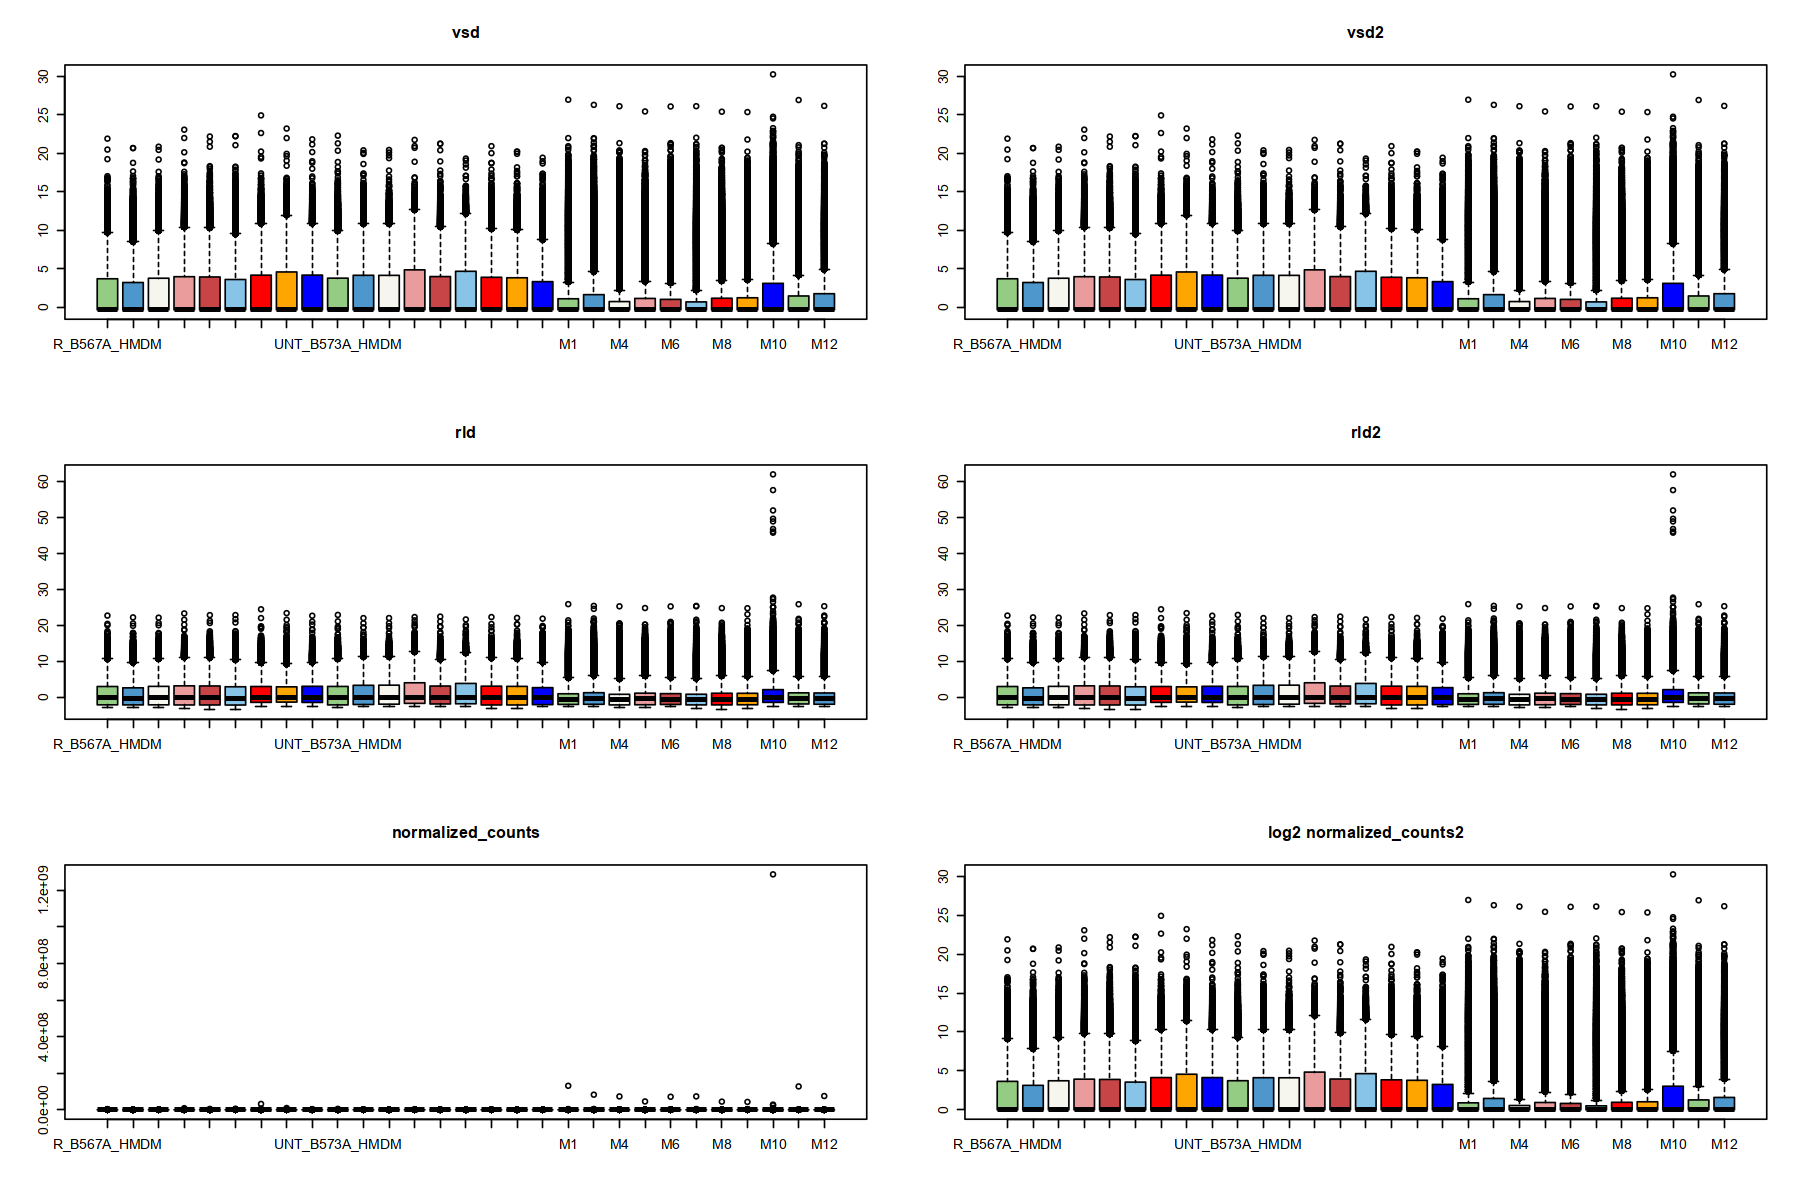

In [8]:
cols <- c("#93cc82","#4d97cd","#f6f5ee","#ea9c9d","#c74546","#88c4e8",'red','orange','blue')
par(mfrow = c(3,2))
boxplot(vsd,main = 'vsd',col = cols)
boxplot(vsd2,main = 'vsd2',col = cols)
boxplot(rld,main = 'rld',col = cols)
boxplot(rld2,main = 'rld2',col = cols)
boxplot(normalized_counts,main = 'normalized_counts',col = cols)
boxplot(log2(normalized_counts2 + 1),main = 'log2 normalized_counts2',col = cols)

,R_B567A_HMDM,R_B567A_HMDM+LPS-IFNg,R_B567A_HMDM+LPS-IFNg+DNT,UNT_B568A_HMDM,UNT_B568A_HMDM+LPS-IFNg,UNT_B568A_HMDM+LPS-IFNg+DNT,anti-TNF_NR_B572A_HMDM,anti-TNF_NR_B572A_HMDM+LPS-IFNg,anti-TNF_NR_B572A_HMDM+LPS-IFNg+DNT,UNT_B573A_HMDM,⋯,M2,M4,M5,M6,M7,M8,M9,M10,M11,M12
5_8S_rRNA,1.071024,2.1481677,0.5573173,1.8078492,0.0000000,0.7429903,3.218413,4.568916,0.000000,1.678914,⋯,0.000000,0.5521128,0.5456383,0.0000000,0.0000000,0.5624640,0.4310846,0.000000,0.000000,0.000000
5S_rRNA,5.643599,0.9860509,3.0949936,0.0000000,3.2054823,0.0000000,0.000000,4.568916,0.000000,1.214822,⋯,0.000000,0.0000000,0.0000000,0.8172886,0.0000000,0.0000000,0.0000000,0.000000,0.000000,0.000000
7SK,0.000000,3.5592852,3.6767479,0.4407547,0.8824835,0.7429903,4.138753,0.000000,0.000000,2.651795,⋯,0.000000,0.0000000,0.0000000,0.0000000,0.0000000,0.9661192,0.4310846,0.000000,0.000000,0.000000
A1BG,4.888695,0.0000000,2.8338807,2.6689616,4.5059742,0.5899848,4.138753,6.522592,0.000000,4.409879,⋯,0.000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.000000,0.000000,2.811646
A1BG-AS1,4.218376,1.7873861,2.2546674,3.3631947,2.0577267,3.3593197,0.000000,0.000000,0.000000,5.702751,⋯,3.906368,8.3214874,8.2841726,8.4419130,2.1341085,1.1322301,0.0000000,0.000000,4.801878,2.589135
A1CF,0.000000,0.0000000,0.0000000,0.0000000,0.2760637,1.0075270,0.000000,5.538199,4.143124,0.000000,⋯,1.459075,0.5521128,1.2503540,0.8172886,0.8855076,0.3084711,0.7625560,4.492144,1.937698,3.004381


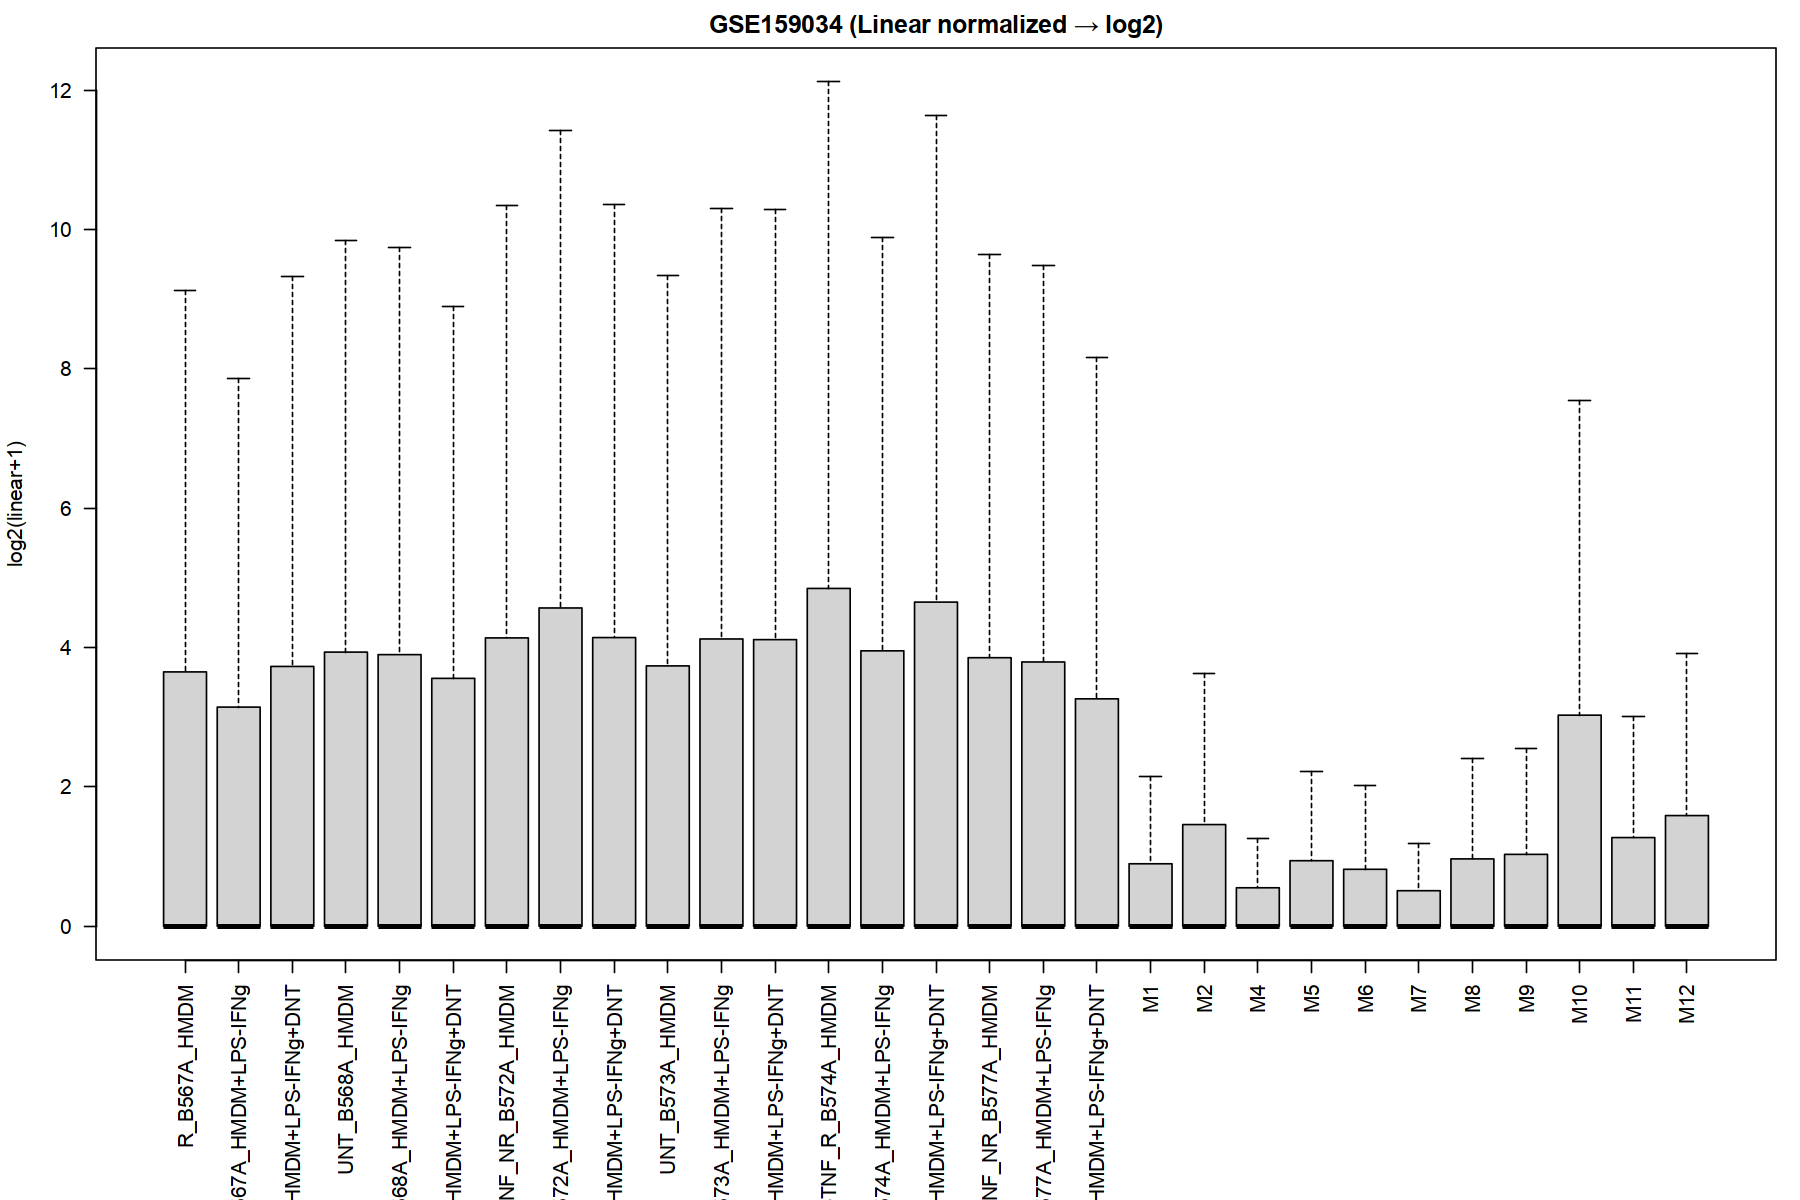

In [9]:
norm_counts <- counts(dds, normalized = TRUE)   
expr_norm_log2 <- log2(norm_counts + 1)
head(expr_norm_log2)

par(mar = c(10,4,2,1))
boxplot(as.data.frame(expr_norm_log2), las = 2, outline = FALSE,
        ylab = "log2(linear+1)", main = "GSE159034 (Linear normalized → log2)")


# Calculate pathway activity scores

In [10]:
# lcpm=expr_norm_log2
# lcpm=log(normalized_counts2+1)
lcpm=rld
# lcpm=vsd

In [11]:
suppressPackageStartupMessages({
  library(GSVA)
  library(dplyr)
  library(tidyr)
})

gene_sets_raw <- list(
  `Inflammatory response` = c(
    "CXCL6","CSF3","CXCL8","CD82","ATP2A2","ADM","PVR","ICAM1","BEST1","RGS1","NAMPT","PDE4B","BDKRB1","TIMP1","PTGIR",
    "IL4R","RIPK2","SPHK1","RHOG","PLAUR","OSMR","F3","EREG","MMP14","SELENOS","IL1B","IRF7","LCP2","ITGA5","RAF1",
    "CHST2","PTGER2","HIF1A","HRH1","CCL7","PDPN","LDLR","CD55","ABCA1","GCH1","TNFSF15","CCL20","SLC31A1","PCDH7",
    "ADRM1","NMI","INHBA","ATP2B1","DCBLD2","BST2","NFKBIA","CXCL10","PTPRE","IL6","KLF6","IL7R"
  ),
  efferocytosis = c(
    "CD24","NR1H3","ADAM10","SIRPB1","ATP8A1","MERTK","CEBPB","XKR4","ANO4","CPT1C","CPT1A","CPT1B","CREB1","CRK","CRKL",
    "SIRPA","MAPK14","CX3CR1","TMEM30B","AGER","DNMT3A","DOCK1","DUSP2","DUSP4","DUSP5","DUSP7","DUSP8","ABCA1","S1PR1",
    "ANO6","ANO5","EPO","EPOR","STAB1","ATP11B","ATP11A","VPS39","VPS8","SIRT1","PLA2G15","ALOX5","PANX1","ALOX15",
    "GAS6","HAVCR1","VPS41","XKR6","ATP11C","GPR132","HIF1A","RAB7B","ANO9","XKR7","IL10","ITGAV","ITGB3","ITGB5","JAK2",
    "ARG1","ARG2","XKR9","LIPA","LRP1","ARNT","MFGE8","NFATC1","NFATC2","NFATC3","NFATC4","ATP2A1","ATP2A2","ATP2A3",
    "ODC1","P2RY2","P2RY6","ANO7","PBX1","GULP1","RAB14","PECAM1","ATP8A2","PPARD","PPARG","SLC66A1","XKR8","SIRPG",
    "STAB2","TMEM30A","AXL","VPS11","MAPK1","MAPK3","MAPK11","MAPK13","MAP2K1","MAP2K2","PROS1","SPHK2","PTGER2","PTGER4",
    "PTGS2","PTK2","ADGRB1","VPS18","PTPN6","PTPN11","RAB5A","RAB5B","RAB5C","RAC1","RXRA","MAPK12","CX3CL1","ANO3",
    "RAB17","SGK1","VPS16","P2RY12","VPS33A","SLC2A1","SLC16A1","BSG","ADAM17","TGFB1","THBS1","C1QA","C1QB","C1QC",
    "TYRO3","NR1H2","UQCRFS1","RAB7A","DUSP16","CALR","CAMK2A","CAMK2B","CAMK2D","CAMK2G","CASP1","CASP3","PLA2G6",
    "CASP7","MEGF11","MEGF10","HAVCR2","SCARF1","ADAM9","SPHK1","SIGLEC10","CH25H","TIMD4","MAPKAPK2","TGFBRAP1","CD36",
    "BCAR1","CD47","ELMO1"
  )
)
clean_sets <- lapply(gene_sets_raw, function(g) {
  g <- toupper(trimws(g))
  unique(g[!is.na(g) & nzchar(g)])
})

overlap_info <- lapply(clean_sets, function(g) {
  list(
    n_total = length(g),
    n_in_matrix = sum(g %in% rownames(lcpm)),
    missing = setdiff(g, rownames(lcpm))
  )
})

gene_sets <- lapply(names(clean_sets), function(nm) {
  intersect(clean_sets[[nm]], rownames(lcpm))
}) |> stats::setNames(names(clean_sets))

non_empty <- vapply(gene_sets, length, integer(1)) > 0
gene_sets <- gene_sets[non_empty]

cat("通路交集统计：\n")
for (nm in names(clean_sets)) {
  oi <- overlap_info[[nm]]
  cat(sprintf(" - %s: %d / %d genes in lcpm%s\n",
              nm, oi$n_in_matrix, oi$n_total,
              if (oi$n_in_matrix == 0) "  [跳过]" else ""))
}

通路交集统计：
 - Inflammatory response: 56 / 56 genes in lcpm
 - efferocytosis: 157 / 157 genes in lcpm


In [12]:
gs <- gsva(
  expr = as.matrix(lcpm),
  gset.idx.list = gene_sets,
  method = "ssgsea",
  ssgsea.norm = TRUE,   
  kcdf = "Gaussian",    
 # kcdf='Poisson',
  mx.diff = FALSE,      
  parallel.sz = 1,      
  verbose = TRUE
)

scores_mat <- gs

scores_long <- scores_mat %>%
  as.data.frame() %>%
  tibble::rownames_to_column("pathway") %>%
  tidyr::pivot_longer(-pathway, names_to = "sample", values_to = "score")

scores_mat=t(scores_mat)
scores_mat=as.data.frame(scores_mat)
scores_mat$sample=rownames(scores_mat)

In [13]:
df=merge(meta,scores_mat,by = 'sample')
df

sample,group,plate,treatment,Inflammatory response,efferocytosis
<chr>,<chr>,<chr>,<fct>,<dbl>,<dbl>
anti-TNF_NR_B572A_HMDM,anti-TNF_NR,B572A,HMDM,1.226378,1.131783
anti-TNF_NR_B572A_HMDM+LPS-IFNg,anti-TNF_NR,B572A,HMDM+LPS-IFNg,1.264912,1.122108
anti-TNF_NR_B572A_HMDM+LPS-IFNg+DNT,anti-TNF_NR,B572A,HMDM+LPS-IFNg+DNT,1.295304,1.137406
anti-TNF_NR_B577A_HMDM,anti-TNF_NR,B577A,HMDM,1.231783,1.079441
anti-TNF_NR_B577A_HMDM+LPS-IFNg,anti-TNF_NR,B577A,HMDM+LPS-IFNg,1.300037,1.081601
anti-TNF_NR_B577A_HMDM+LPS-IFNg+DNT,anti-TNF_NR,B577A,HMDM+LPS-IFNg+DNT,1.309905,1.121367
anti-TNF_R_B574A_HMDM,anti-TNF_R,B574A,HMDM,1.184386,1.080987
anti-TNF_R_B574A_HMDM+LPS-IFNg,anti-TNF_R,B574A,HMDM+LPS-IFNg,1.248093,1.079396
anti-TNF_R_B574A_HMDM+LPS-IFNg+DNT,anti-TNF_R,B574A,HMDM+LPS-IFNg+DNT,1.275094,1.106465


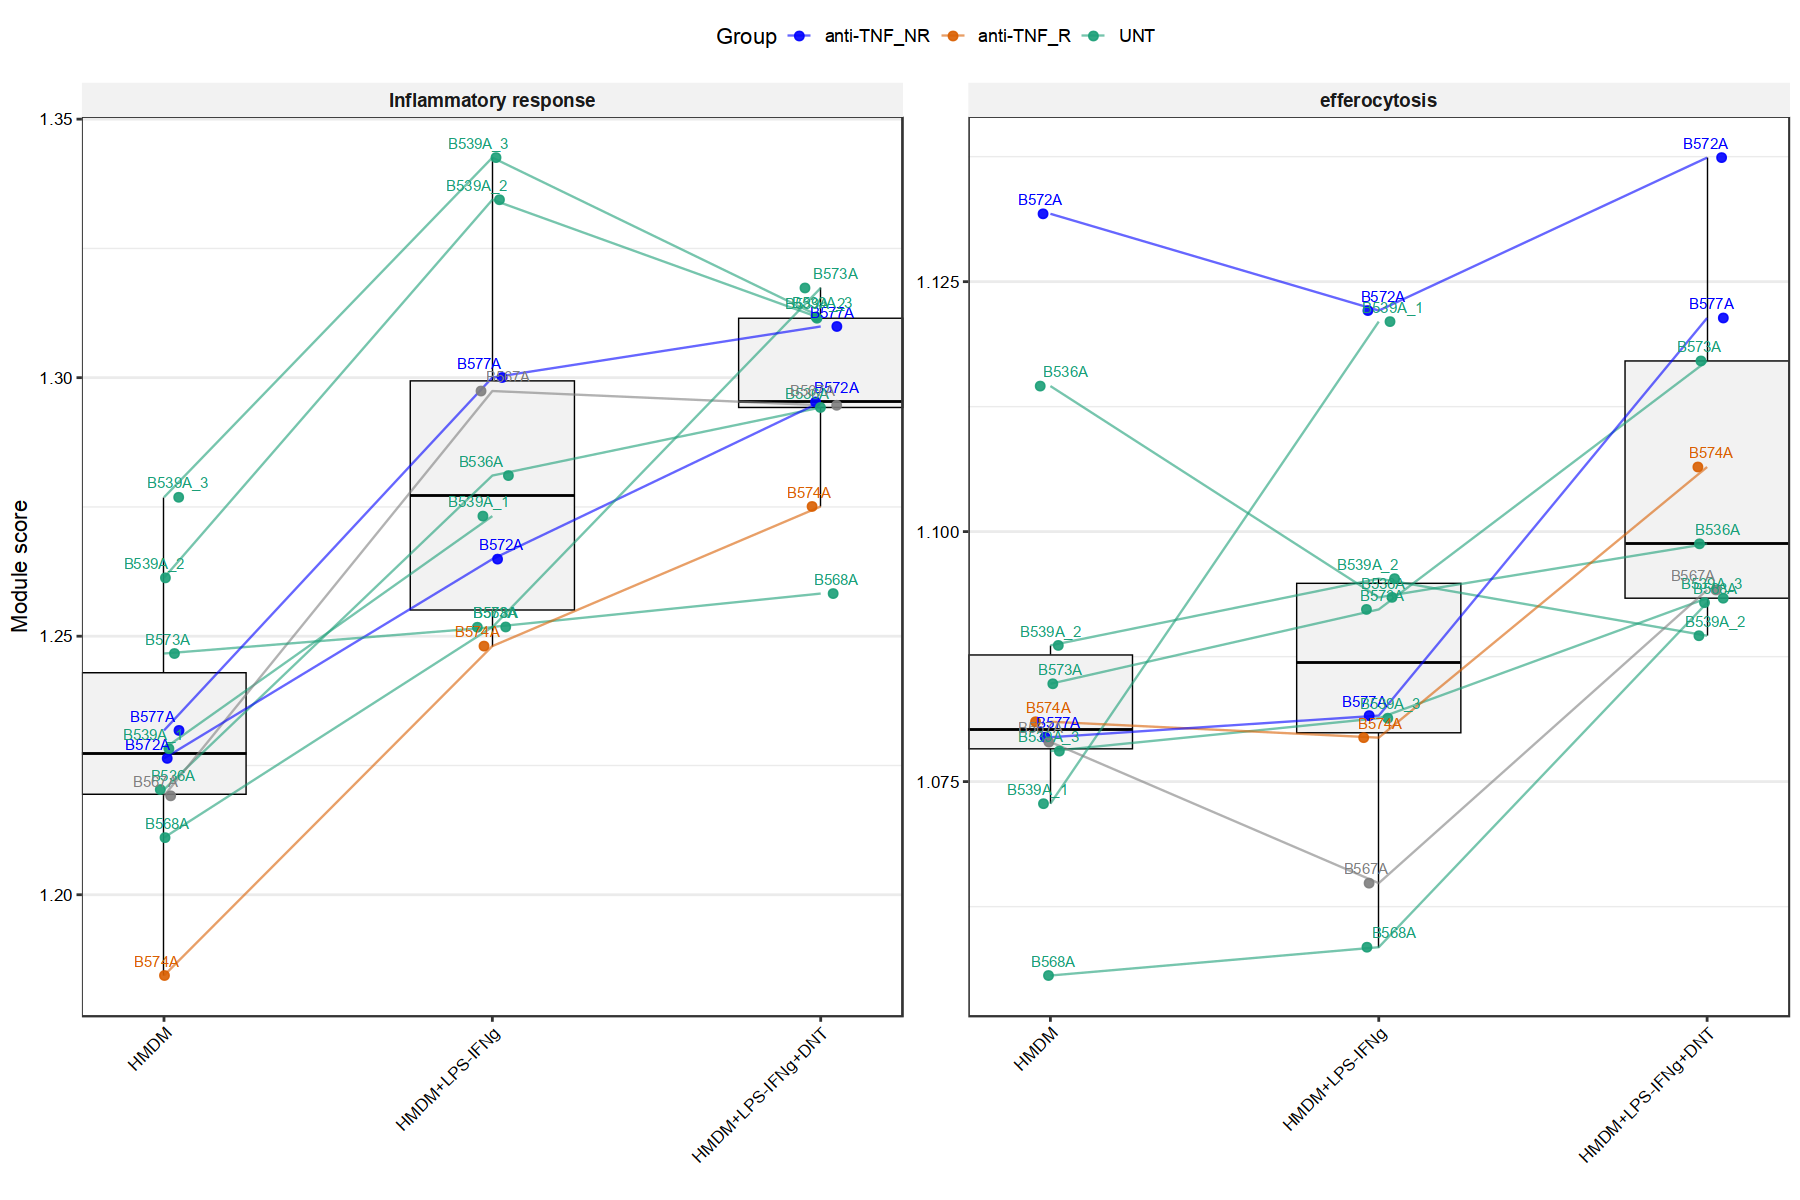

In [14]:
module_cols <- c(
  "Inflammatory response",
  "efferocytosis"
)

target_treatments <- c("HMDM", "HMDM+LPS-IFNg", "HMDM+LPS-IFNg+DNT")
df_long <- df %>%
  filter(treatment %in% target_treatments) %>%
  mutate(
    person = plate, 
    treatment = factor(treatment, levels = target_treatments)
  ) %>%
  pivot_longer(
    cols      = all_of(module_cols),
    names_to  = "module",
    values_to = "score"
  ) %>%
  mutate(
    module = factor(module, levels = module_cols),
    group  = factor(group)  # anti-TNF R / UNT
  )

pos_jitter <- position_jitter(width = 0.05, height = 0)
p_pair <- ggplot(df_long, aes(x = treatment, y = score)) +
  geom_boxplot(
    fill          = "grey95",
    color         = "black",
    outlier.shape = NA,
    width         = 0.5,
    linewidth     = 0.3
  ) +
  geom_line(
    aes(group = person, color = group),
    linewidth = 0.5,
    alpha     = 0.6
  ) +
  geom_point(
    aes(color = group),
    size      = 2,
    alpha     = 0.9,
    position  = pos_jitter
  ) +
  geom_text(
    aes(label = person, color = group),
    position  = pos_jitter,
    size      = 3,
    vjust     = -0.8,     
    show.legend = FALSE   
  ) +
  scale_color_manual(values = c("anti-TNF_NR" = "blue", 'anti-TNF_R'="#D95F02", "UNT" = "#1B9E77")) +
  scale_x_discrete(expand = expansion(mult = c(0.1, 0.1))) +
  labs(
    x     = "",
    y     = "Module score",
    color = "Group"
  ) +
  facet_wrap(~ module, scales = "free_y", ncol = 3) +
  theme_bw(base_size = 13) +
  theme(
    legend.position   = "top",
    strip.background  = element_rect(fill = "grey95", colour = NA),
    strip.text        = element_text(size = 11, face = "bold"),
    plot.title        = element_text(size = 18, face = "bold", hjust = 0.5),
    axis.text.x       = element_text(size = 10, angle = 45, hjust = 1, color="black"),
    axis.text.y       = element_text(size = 10, color="black"),
    panel.grid.major.x = element_blank()
  )
print(p_pair)

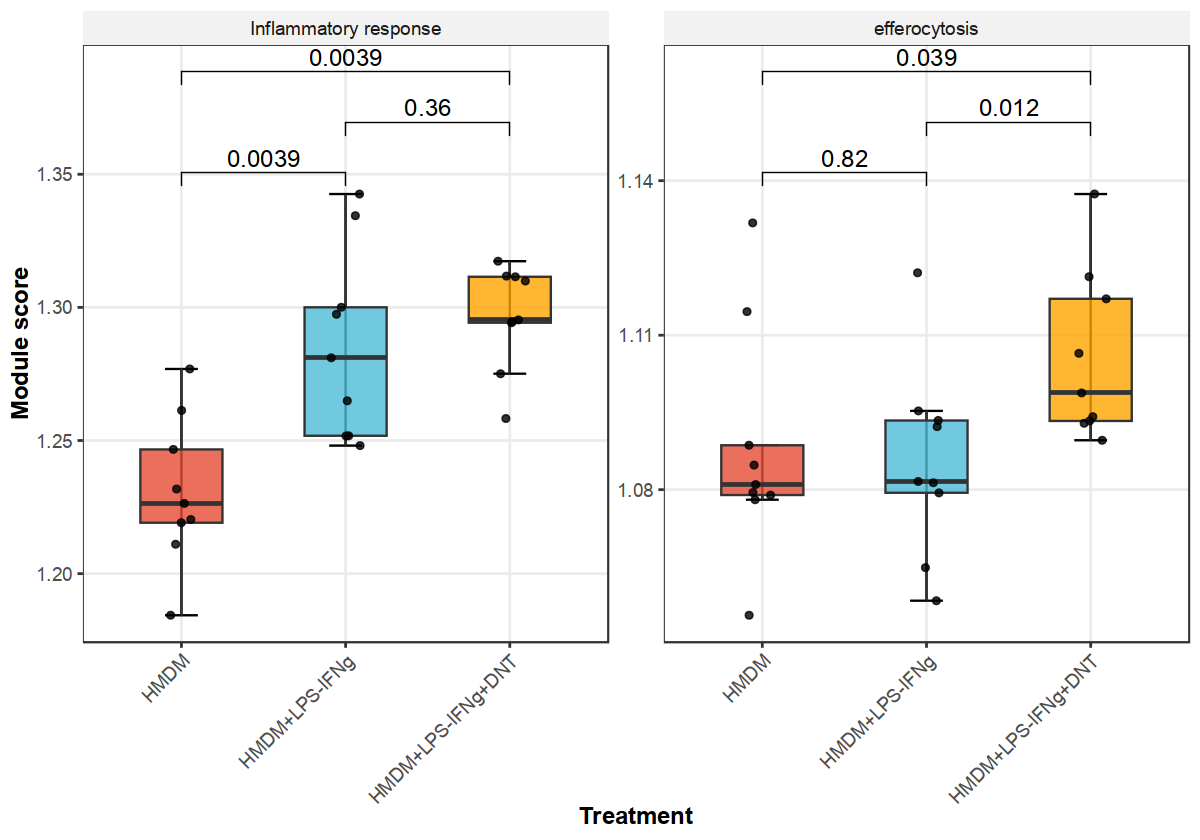

In [15]:
module_cols <- c(
 "Inflammatory response", "efferocytosis"
)

target_treatments <- c("HMDM", "HMDM+LPS-IFNg", "HMDM+LPS-IFNg+DNT")

df_long <- df %>%
  filter(treatment %in% target_treatments) %>%
  dplyr::select(treatment, plate, all_of(module_cols)) %>%
  pivot_longer(all_of(module_cols), names_to = "module", values_to = "score") %>%
  mutate(
    module = factor(module, levels = module_cols),
    treatment = factor(treatment, levels = target_treatments)
  ) %>%
  filter(!is.na(score))


df_clean <- df_long %>%
  group_by(module, plate) %>%
  filter(n() == 3) %>% 
  ungroup() %>%
  arrange(module, treatment, plate)


my_comparisons <- list(
  c("HMDM", "HMDM+LPS-IFNg"),
  c("HMDM+LPS-IFNg", "HMDM+LPS-IFNg+DNT"),
  c("HMDM", "HMDM+LPS-IFNg+DNT")
)

p <- ggplot(df_clean[df_clean$module %in% c('efferocytosis','Inflammatory response'),], aes(x = treatment, y = score, fill = treatment)) +
  stat_boxplot(geom = "errorbar", width = 0.2, size = 0.5, position = position_dodge(0.6)) +
  geom_boxplot(width = 0.5, outlier.shape = NA, size = 0.5, alpha = 0.8) +
  geom_jitter(
    position = position_jitter(width = 0.1),
    size = 1.5,
    alpha = 0.8
  ) +
  scale_fill_manual(values = c("#E64B35", "#4DBBD5", "orange")) + 
  labs(x = "Treatment", y = "Module score") +
  theme_bw(base_size = 13) + 
  theme(
    legend.position = "none",
    strip.background = element_rect(fill = "grey95", colour = NA), 
    strip.text = element_text(size = 11),
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    axis.title = element_text(size = 14, face = "bold"),
    axis.text.x = element_text(size = 11, angle = 45, hjust = 1),
    axis.text.y = element_text(size = 11),
    panel.grid.major = element_line(colour = "grey92"),
    panel.grid.minor = element_blank()
  ) +
  
  facet_wrap(~ module, scales = "free_y", ncol = 5) +
  
  # --- 5. 统计检验 ---
  stat_compare_means(
    # aes(label = ..p.format..),
      aes(label = sprintf("p = %.3f", as.numeric(..p.format..))),
    comparisons = my_comparisons,
    method = "wilcox.test",
    paired = TRUE,
    hide.ns = FALSE,
    label.y.npc = c(0.95, 0.87, 0.79),
    size = 5 # 字体适中
  )

print(p)

In [16]:
my_comparisons <- list(
  c("HMDM", "HMDM+LPS-IFNg"),
  c("HMDM+LPS-IFNg", "HMDM+LPS-IFNg+DNT"),
  c("HMDM", "HMDM+LPS-IFNg+DNT")
)

stat_tbl_clean <- compare_means(
  score ~ treatment,
  data            = df_clean,
  group.by        = "module",   
  method          = "wilcox.test",
  paired          = TRUE,
  p.adjust.method = "none"
) %>%
  mutate(
    p_detailed = sprintf("%.5f", p)
  ) %>%
  arrange(module, p)

stat_tbl_clean
# write.csv(stat_tbl_clean, "HMDM_Paired_Wilcox_Detailed.csv", row.names = FALSE)

module,.y.,group1,group2,p,p.adj,p.format,p.signif,method,p_detailed
<fct>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
Inflammatory response,score,HMDM,HMDM+LPS-IFNg,0.00390625,0.0039,0.0039,**,Wilcoxon,0.00391
Inflammatory response,score,HMDM,HMDM+LPS-IFNg+DNT,0.00390625,0.0039,0.0039,**,Wilcoxon,0.00391
Inflammatory response,score,HMDM+LPS-IFNg,HMDM+LPS-IFNg+DNT,0.35937500,0.3600,0.3594,ns,Wilcoxon,0.35938
efferocytosis,score,HMDM+LPS-IFNg,HMDM+LPS-IFNg+DNT,0.01171875,0.0120,0.0117,*,Wilcoxon,0.01172
efferocytosis,score,HMDM,HMDM+LPS-IFNg+DNT,0.03906250,0.0390,0.0391,*,Wilcoxon,0.03906
efferocytosis,score,HMDM,HMDM+LPS-IFNg,0.82031250,0.8200,0.8203,ns,Wilcoxon,0.82031


# Perform GSEA enrichment analysis

In [17]:
term2gene <- stack(gene_sets_raw) %>% 
  dplyr::select(ind, values) %>% 
  dplyr::rename(term = ind, gene = values)

term2gene_2=term2gene[term2gene$term %in% c('efferocytosis'),]
term2gene_2

,term,gene
,<fct>,<chr>
57,efferocytosis,CD24
58,efferocytosis,NR1H3
59,efferocytosis,ADAM10
60,efferocytosis,SIRPB1
61,efferocytosis,ATP8A1
62,efferocytosis,MERTK
63,efferocytosis,CEBPB
64,efferocytosis,XKR4
65,efferocytosis,ANO4


In [18]:
min_baseMean <- 1
res_paired_LPS <- results(dds, contrast = c("treatment", "HMDM+LPS-IFNg", "HMDM"))
df_LPS <- as.data.frame(res_paired_LPS) 

df_LPS <- na.omit(df_LPS)
df_LPS <- df_LPS[df_LPS$baseMean > min_baseMean, ]

gene_list_LPS <- df_LPS$log2FoldChange
names(gene_list_LPS) <- rownames(df_LPS)
gene_list_LPS <- sort(gene_list_LPS, decreasing = TRUE) 

print(paste("LPS组 GSEA 输入基因数:", length(gene_list_LPS))) 


res_paired_DNT <- results(dds, contrast = c("treatment", "HMDM+LPS-IFNg+DNT", "HMDM"))
df_DNT <- as.data.frame(res_paired_DNT)
df_DNT <- na.omit(df_DNT)
df_DNT <- df_DNT[df_DNT$baseMean > min_baseMean, ] 

gene_list_DNT <- df_DNT$log2FoldChange
names(gene_list_DNT) <- rownames(df_DNT)
gene_list_DNT <- sort(gene_list_DNT, decreasing = TRUE)

print(paste("DNT组 GSEA 输入基因数:", length(gene_list_DNT)))


gsea_LPS_res <- GSEA(
  gene_list_LPS,
  TERM2GENE = term2gene_2,
  pvalueCutoff = 1,  
  minGSSize = 5,
  maxGSSize = 2000,
  eps = 0,
  seed = 123 
)

gsea_DNT_res <- GSEA(
  gene_list_DNT,
  TERM2GENE = term2gene_2,
  pvalueCutoff = 1,
  minGSSize = 5,
  maxGSSize = 2000,
  eps = 0,
  seed = 123
)

[1] "LPS组 GSEA 输入基因数: 22150"
[1] "DNT组 GSEA 输入基因数: 21190"


preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.01% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
leading edge analysis...

done...

preparing geneSet collections...

GSEA analysis...

leading edge analysis...

done...



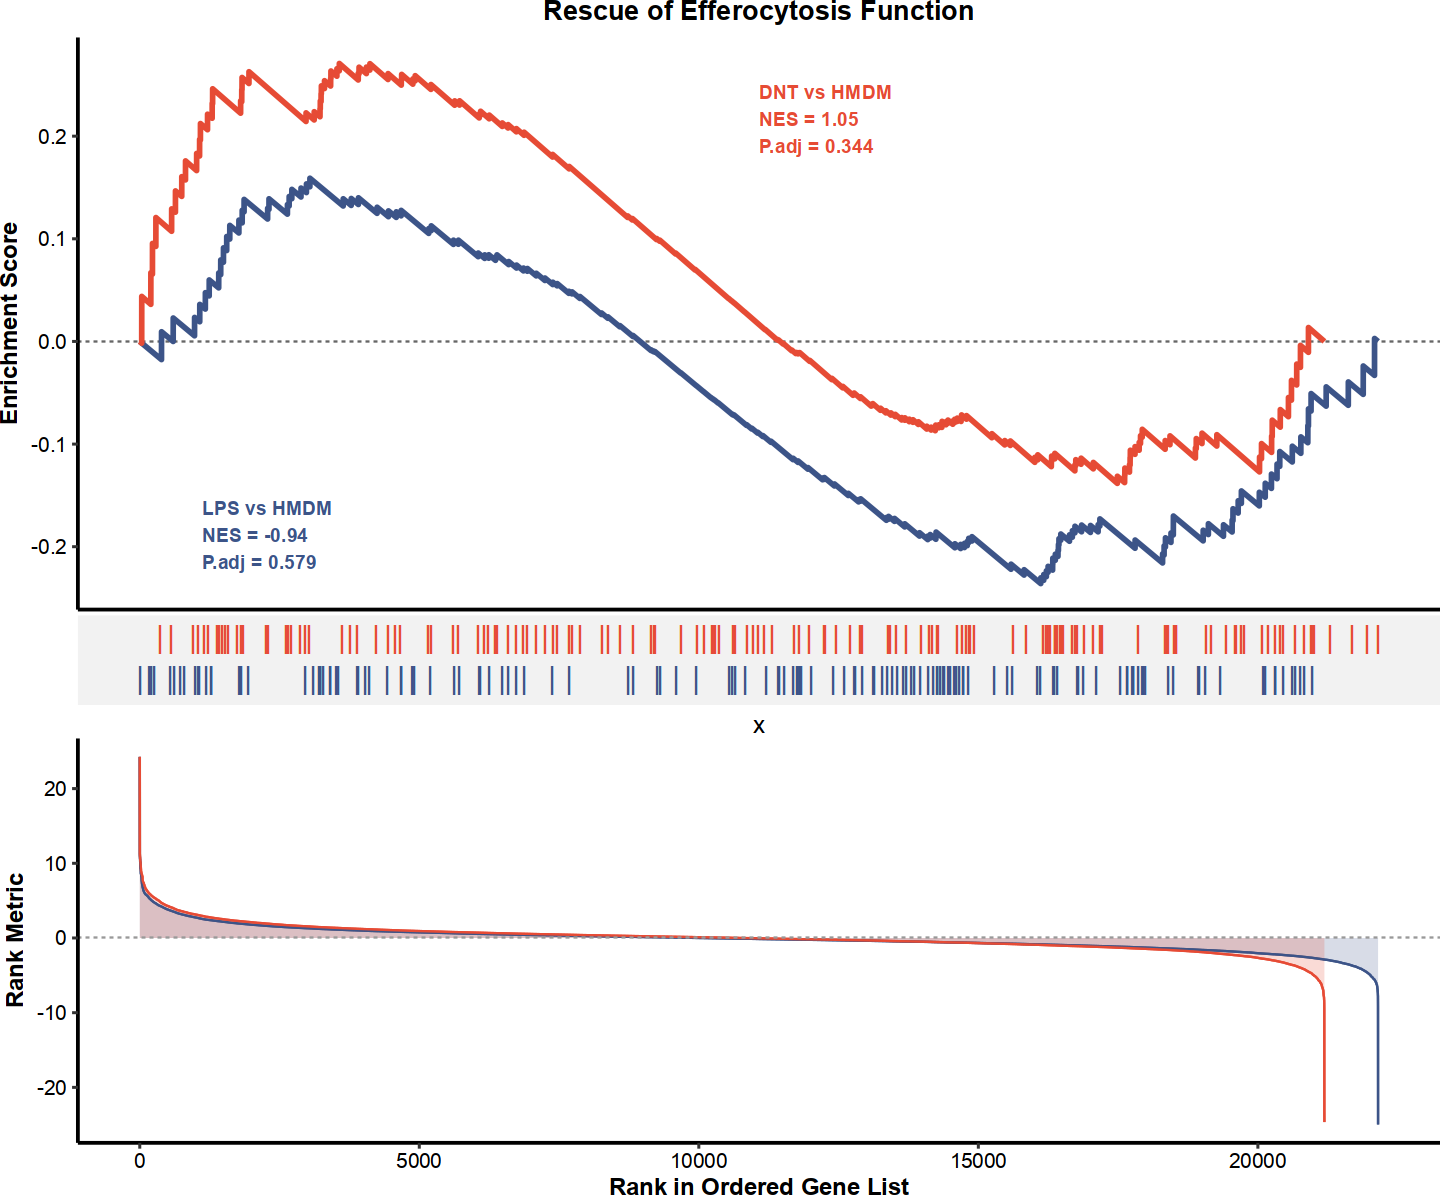

In [19]:
id_LPS <- gsea_LPS_res@result$ID[1]
d_LPS  <- enrichplot:::gsInfo(gsea_LPS_res, geneSetID = id_LPS)
d_LPS$group <- "LPS vs HMDM"

nes_LPS  <- round(gsea_LPS_res@result[1, "NES"], 2)
pval_LPS <- gsea_LPS_res@result[1, "p.adjust"]
pval_txt_LPS <- ifelse(pval_LPS < 0.001, "< 0.001", paste0("= ", round(pval_LPS, 3)))

id_DNT <- gsea_DNT_res@result$ID[1]
d_DNT  <- enrichplot:::gsInfo(gsea_DNT_res, geneSetID = id_DNT)
d_DNT$group <- "DNT vs HMDM" 

nes_DNT  <- round(gsea_DNT_res@result[1, "NES"], 2)
pval_DNT <- gsea_DNT_res@result[1, "p.adjust"]
pval_txt_DNT <- ifelse(pval_DNT < 0.001, "< 0.001", paste0("= ", round(pval_DNT, 3)))

plot_data <- rbind(d_LPS, d_DNT)
plot_data$group <- factor(plot_data$group, levels = c("LPS vs HMDM", "DNT vs HMDM"))
npg_colors <- c("#3C5488", "#E64B35")

get_barcode <- function(gsea_obj, grp) {
  pid <- gsea_obj@result$ID[1]
  geneSet <- gsea_obj@geneSets[[pid]]
  geneList <- gsea_obj@geneList
  hit_ind <- match(geneSet, names(geneList))
  hit_ind <- hit_ind[!is.na(hit_ind)]
  data.frame(x = hit_ind, group = grp)
}
bar_LPS <- get_barcode(gsea_LPS_res, "LPS vs HMDM")
bar_DNT <- get_barcode(gsea_DNT_res, "DNT vs HMDM")
bar_all <- rbind(bar_LPS, bar_DNT)
bar_all$group <- factor(bar_all$group, levels = c("DNT vs HMDM", "LPS vs HMDM")) 

metric_LPS <- data.frame(
  x = 1:length(gsea_LPS_res@geneList), 
  y = gsea_LPS_res@geneList, 
  group = "LPS vs HMDM"
)
metric_DNT <- data.frame(
  x = 1:length(gsea_DNT_res@geneList), 
  y = gsea_DNT_res@geneList, 
  group = "DNT vs HMDM"
)
metric_all <- rbind(metric_LPS, metric_DNT)
metric_all$group <- factor(metric_all$group, levels = c("LPS vs HMDM", "DNT vs HMDM"))

p1 <- ggplot(plot_data, aes(x = x, y = runningScore, color = group)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey40", size = 0.5) +
  # geom_area(alpha = 0.1, position = "identity") + 
  geom_line(size = 1.2) +
  scale_color_manual(values = npg_colors) +

  annotate("text", x = max(plot_data$x) * 0.05, y = min(plot_data$runningScore) * 0.8, 
           label = paste0("LPS vs HMDM\nNES = ", nes_LPS, "\nP.adj ", pval_txt_LPS), 
           color = npg_colors[1], hjust = 0, fontface = "bold", size = 4) +
  
  annotate("text", x = max(plot_data$x) * 0.5, y = max(plot_data$runningScore) * 0.8, 
           label = paste0("DNT vs HMDM\nNES = ", nes_DNT, "\nP.adj ", pval_txt_DNT), 
           color = npg_colors[2], hjust = 0, fontface = "bold", size = 4) +
  
  labs(y = "Enrichment Score", title = "Rescue of Efferocytosis Function") +
  theme_classic(base_size = 14) +
  theme(
    axis.line = element_line(size = 0.8, color = "black"),
    axis.text.y = element_text(color = "black", size = 12),
    axis.title.y = element_text(face = "bold", size = 14),
    plot.title = element_text(hjust = 0.5, face = "bold", size = 16),
    legend.position = "none",
    
    axis.title.x = element_blank(),
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    plot.margin = margin(b = 0, unit = "cm") 
  )

p2 <- ggplot(bar_all, aes(x = x, y = group, color = group)) +
  geom_point(shape = "|", size = 6) + 
  scale_color_manual(values = npg_colors) +
  labs(y = NULL) +
  theme_classic(base_size = 14) +
  theme(
    axis.line = element_blank(),
    axis.ticks = element_blank(),
    axis.text = element_blank(), 
    legend.position = "none",
    panel.background = element_rect(fill = "grey95", color = NA), 
    plot.margin = margin(t = 0, b = 0, unit = "cm")
  )

p3 <- ggplot(metric_all, aes(x = x, y = y, color = group, fill = group)) +
  geom_area(alpha = 0.2, position = "identity") + 
  geom_line() +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey60") +
  scale_color_manual(values = npg_colors) +
  scale_fill_manual(values = npg_colors) +
  labs(x = "Rank in Ordered Gene List", y = "Rank Metric") +
  theme_classic(base_size = 14) +
  theme(
    axis.line = element_line(size = 0.8, color = "black"),
    axis.text = element_text(color = "black", size = 12),
    axis.title = element_text(face = "bold", size = 14),
    legend.position = "none", 
    plot.margin = margin(t = 0, unit = "cm")
  )

final_plot <- plot_grid(
  p1, p2, p3, 
  ncol = 1, 
  align = "v",      
  axis = "lr",      
  rel_heights = c(2, 0.4, 1.5) 
)

print(final_plot)
ggsave("Fig_GSEA_Rescue_CNS_Combined_DualLines_2.pdf", final_plot, width = 10, height = 9)